In [1]:
import h5py

file_path = r"Dataset/archive/GOLD_XYZ_OSC.0001_1024.hdf5"

with h5py.File(file_path, "r") as f:
    print("Keys:")
    for key in f.keys():
        print(key)

Keys:
X
Y
Z


In [2]:
with h5py.File(file_path, "r") as f:
    for key in f.keys():
        print(key, f[key].shape)

X (2555904, 1024, 2)
Y (2555904, 24)
Z (2555904, 1)


In [3]:
import h5py
import numpy as np



with h5py.File(file_path, "r") as f:
    X = f["X"]
    Y = f["Y"]
    Z = f["Z"]

    print("X shape:", X.shape)
    print("Y shape:", Y.shape)
    print("Z shape:", Z.shape)

    print("\nFirst Y:")
    print(Y[0])

    print("\nFirst Z:")
    print(Z[0])

    print("\nX[0] shape:")
    print(X[0].shape)

    print("\nFirst 5 IQ samples:")
    print(X[0][:120])

X shape: (2555904, 1024, 2)
Y shape: (2555904, 24)
Z shape: (2555904, 1)

First Y:
[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First Z:
[-20]

X[0] shape:
(1024, 2)

First 5 IQ samples:
[[ 4.20273952e-02  2.34763235e-01]
 [-2.72882611e-01  4.05134916e-01]
 [-2.67072618e-01  2.27498889e-01]
 [-3.14850867e-01 -1.76458597e-01]
 [ 9.63341236e-01 -1.02571023e+00]
 [ 1.87244624e-01  6.44536376e-01]
 [ 2.60705411e-01 -4.00602192e-01]
 [-1.38889417e-01  3.37220818e-01]
 [ 3.51226389e-01 -3.00818056e-01]
 [ 6.83884501e-01 -1.90601695e+00]
 [ 1.19307786e-01  7.23491237e-02]
 [-1.77766070e-01 -3.49935830e-01]
 [ 4.21254300e-02 -2.73146898e-01]
 [ 1.16819859e+00  1.35799253e+00]
 [ 1.13426137e+00  4.34401125e-01]
 [ 3.39727253e-02 -9.00930226e-01]
 [ 1.82389474e+00 -1.91117674e-01]
 [ 1.11155123e-01  3.19545120e-01]
 [ 8.38508904e-01  3.62890035e-01]
 [ 1.07418180e+00  3.98637831e-01]
 [ 3.25316995e-01 -5.00284135e-01]
 [-7.12064922e-01 -2.04506859e-01]
 [-5.76841295e-01  1.49948746e-01]
 [

In [4]:
f= h5py.File(file_path , "r")

In [5]:
X

<Closed HDF5 dataset>

In [6]:
import h5py

f = h5py.File("Dataset/archive/GOLD_XYZ_OSC.0001_1024.hdf5", "r")
x = f["X"]
print(x[0].shape)

(1024, 2)


In [7]:
y= f["Y"]
z=f["Z"]
labels = np.argmax(y , axis = 1)

In [8]:
print("Class IDs:", np.unique(labels))

Class IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [9]:
import json
with open(r"Dataset/archive/classes-fixed.json" , "r") as f:
    classes = json.load(f)
print(classes)

['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']


In [10]:
sample = x[319488][0]
sample

array([-0.50679684,  0.4923161 ], dtype=float32)

In [11]:
sample[:10]

array([-0.50679684,  0.4923161 ], dtype=float32)

In [12]:
label = np.argmax(y[319488])
snr = z[319488][0]

In [13]:
print("Class ID:", label)
print("Modulation:", classes[label])
print("SNR:", snr, "dB")

Class ID: 3
Modulation: BPSK
SNR: -20 dB


In [14]:
for i in [0, 4096, 8192, 106496, 106498]:
    print(i, np.argmax(y[i]), z[i][0])

0 0 -20
4096 0 -18
8192 0 -16
106496 1 -20
106498 1 -20


Text(0, 0.5, 'Amplitude')

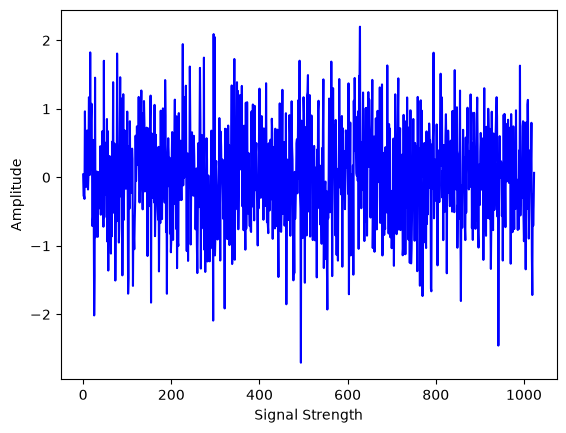

In [15]:
# Now I will plot te see how the signal works
import matplotlib.pyplot as plt
first = x[0]

plt.plot(first[: , 0] , color = "blue" )
plt.xlabel("Signal Strength")
plt.ylabel("Amplitude")

Text(0, 0.5, 'Amplitude')

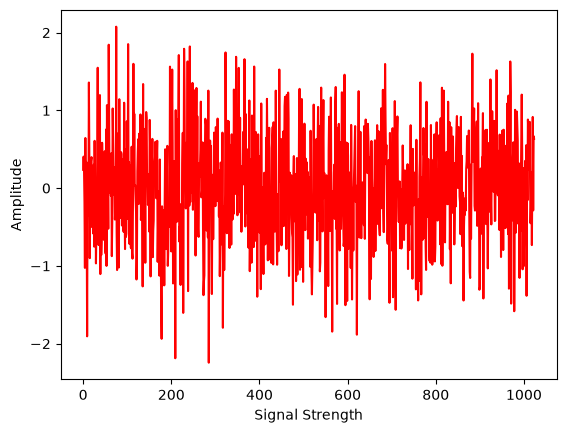

In [16]:
plt.plot( first[: ,1] , color = "red" )
plt.xlabel("Signal Strength")
plt.ylabel("Amplitude")

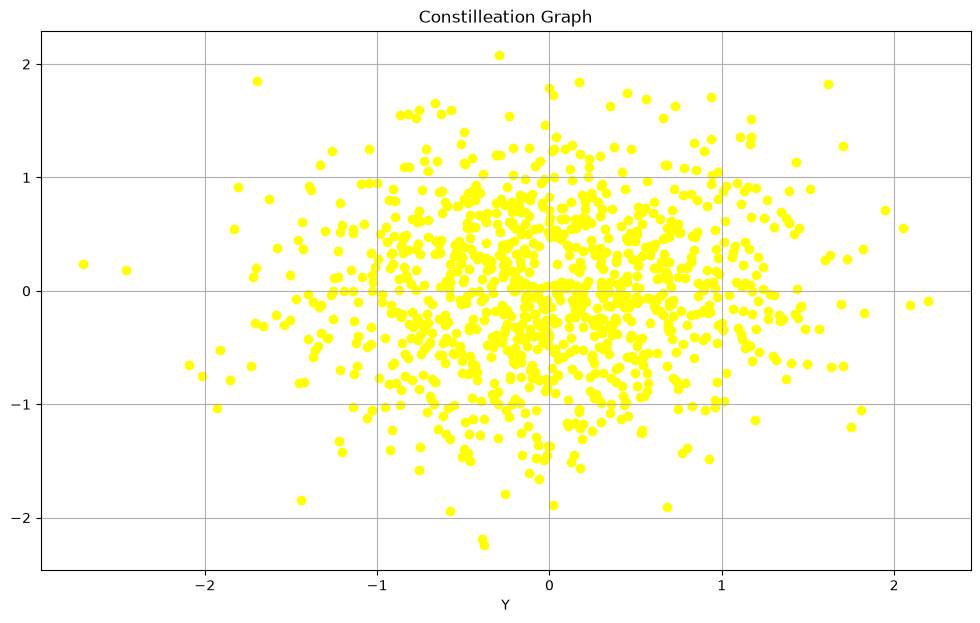

In [17]:
plt.figure(figsize=(12,7))
plt.scatter(first[: , 0] , first[: ,1] , color = "yellow" )

plt.xlabel("X")
plt.xlabel("Y")
plt.title("Constilleation Graph")

plt.grid()


In [18]:
for i in [0,100,189000,10000,969999]:
    label = np.argmax(y[i])
    snr = z[i][0]
    print(f"{i}-->{classes[label]} --> {snr}"
        
    )
    


0-->OOK --> -20
100-->OOK --> -20
189000-->4ASK --> 20
10000-->OOK --> -16
969999-->32APSK --> -16


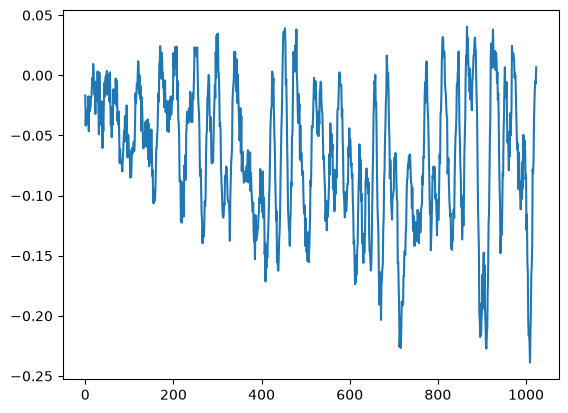

In [19]:
g = 189000
s1 = x[g]
i = s1[: , 0]
q=s1[: ,1]
plt.plot(i)

In [20]:
print(np.unique(z))

[-20 -18 -16 -14 -12 -10  -8  -6  -4  -2   0   2   4   6   8  10  12  14
  16  18  20  22  24  26  28  30]


In [21]:
for i in np.unique(z[:,0]):
    count = np.sum(z[:, 0] == i)
    print(f"{i} --> {count}")

-20 --> 98304
-18 --> 98304
-16 --> 98304
-14 --> 98304
-12 --> 98304
-10 --> 98304
-8 --> 98304
-6 --> 98304
-4 --> 98304
-2 --> 98304
0 --> 98304
2 --> 98304
4 --> 98304
6 --> 98304
8 --> 98304
10 --> 98304
12 --> 98304
14 --> 98304
16 --> 98304
18 --> 98304
20 --> 98304
22 --> 98304
24 --> 98304
26 --> 98304
28 --> 98304
30 --> 98304


In [22]:
for g in np.unique(labels):
    count = np.sum(labels == g)
    print(f"{classes[g]}--> {count}")

OOK--> 106496
4ASK--> 106496
8ASK--> 106496
BPSK--> 106496
QPSK--> 106496
8PSK--> 106496
16PSK--> 106496
32PSK--> 106496
16APSK--> 106496
32APSK--> 106496
64APSK--> 106496
128APSK--> 106496
16QAM--> 106496
32QAM--> 106496
64QAM--> 106496
128QAM--> 106496
256QAM--> 106496
AM-SSB-WC--> 106496
AM-SSB-SC--> 106496
AM-DSB-WC--> 106496
AM-DSB-SC--> 106496
FM--> 106496
GMSK--> 106496
OQPSK--> 106496


In [23]:
for i in range (0,500000 , 50000):
    label = np.argmax(y[i])
    print(label)

0
0
0
1
1
2
2
3
3
4


In [24]:
no=1096
label = np.argmax(y[no])
label
classes[label]

'OOK'

In [25]:
x[0]


array([[ 0.0420274 ,  0.23476323],
       [-0.2728826 ,  0.40513492],
       [-0.26707262,  0.22749889],
       ...,
       [-0.7055947 , -0.28693035],
       [-0.41157472,  0.66826206],
       [ 0.06487698,  0.6358149 ]], shape=(1024, 2), dtype=float32)

In [26]:
for i in range (0 , 100):
    for j in [0]:
        val = x[0][i][j]
        val1 = x[0][i][j+1]
        d = (val)**2 + (val)**2
        print(np.sqrt(d))
        
        

0.05943571
0.3859143
0.3776977
0.44526637
1.3623703
0.2648039
0.3686931
0.1964193
0.49670914
0.96715873
0.1687267
0.2513992
0.059574354
1.6520823
1.6040878
0.04804469
2.5793767
0.15719709
1.1858306
1.5191225
0.4600677
1.0070119
0.81577677
0.77156436
0.7150778
2.8514025
2.0310934
2.0572903
1.2367038
0.5590294
0.28267258
0.11899959
0.13456924
1.2297359
0.11079021
0.12262378
0.03480202
0.6383308
0.40940446
0.6425057
0.772211
0.020265548
0.2813293
0.2084861
0.9574126
0.31036985
1.0199449
2.4065344
0.8274865
0.06459589
0.030100146
0.71447784
0.3642017
0.3082762
1.2040268
1.328984
0.9536538
1.9247203
0.242059
0.75298667
0.4395975
0.20485796
0.8158514
1.5747147
0.3388151
1.2180427
0.7372664
0.3026245
1.9643414
0.35425064
0.7335391
0.69804406
0.0001913834
2.1310523
0.9066715
0.40986744
0.9062957
2.5556962
0.75518095
0.21314935
0.60826325
1.3463455
1.0311958
0.8055839
2.0663264
0.39280742
0.95077735
0.29445612
1.628492
2.0242887
0.09346916
1.7165192
0.8807573
0.11622352
0.96999675
0.08409884
0.

In [27]:
no_of_samples = 106496
samples_per_snr = 4096
sample_take = 150
X_list = []
Y_list = []
Z_list = []
for class_id in range (24):
    class_start = no_of_samples * class_id
    for snr_id in range (26):
        start = class_start + snr_id*samples_per_snr
        end = start + sample_take
        X_list.append(x[start:end])
        Y_list.append(y[start:end])
        Z_list.append(z[start:end])
X_subset = np.concatenate(X_list , axis=0)
Y_subset = np.concatenate(Y_list , axis=0)
Z_subset = np.concatenate(Z_list , axis=0)
        
        
    

In [28]:
print("X_subset:", X_subset.shape)
print("Y_subset:", Y_subset.shape)
print("Z_subset:", Z_subset.shape)

X_subset: (93600, 1024, 2)
Y_subset: (93600, 24)
Z_subset: (93600, 1)


In [29]:
Y_subset

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1]], shape=(93600, 24))

In [30]:
label1 = np.argmax(Y_subset , axis=1)


In [31]:
#  Amplitude for the extracted data 
I = X_subset[: , : ,0]
Q = X_subset[: , : ,1]
amplitude = np.sqrt(I**2+Q**2)
amplitude.shape

(93600, 1024)

In [32]:
import numpy as np
import pandas as pd

from scipy.stats import skew as scipy_skew
from scipy.stats import kurtosis as scipy_kurtosis
amp = np.sqrt(I**2 + Q**2)
phase = np.arctan2(Q, I)

# Unwrapped phase for instantaneous frequency
phase_unwrapped = np.unwrap(phase, axis=1)


# 2. Basic Amplitude Statistics
amp_mean = amp.mean(axis=1)
amp_std = amp.std(axis=1)
amp_max = amp.max(axis=1)
amp_min = amp.min(axis=1)
amp_ptp = amp_max - amp_min
amp_var = amp_std**2


# 3. Power & Ratios
power = np.mean(I**2 + Q**2, axis=1)

RMS_amp = np.sqrt(power)

crest_factor = amp_max / (RMS_amp + 1e-12)

papr = 10 * np.log10(
    (amp_max**2) / (power + 1e-12)
)


# 4. Instantaneous Frequency
inst_freq = np.diff(phase_unwrapped, axis=1)

inst_freq_mean = inst_freq.mean(axis=1)
inst_freq_std = inst_freq.std(axis=1)


# 5. Higher-Order Amplitude Moments

amp_mean_col = amp.mean(axis=1, keepdims=True)
amp_centered = amp - amp_mean_col

amp_skew = (
    np.mean(amp_centered**3, axis=1)
    / (amp_std**3 + 1e-12)
)

amp_kurtosis = (
    np.mean(amp_centered**4, axis=1)
    / (amp_std**4 + 1e-12)
    - 3
)


# 6. Scipy Skewness & Kurtosis
# Use aliases so they cannot conflict with variables named
# skew or kurtosis elsewhere in the notebook.

amp_kurt = scipy_kurtosis(amp, axis=1)

I_skew = scipy_skew(I, axis=1)
Q_skew = scipy_skew(Q, axis=1)


# 7. Feature Names
feature_names = [
    "I_mean",
    "I_std",
    "Q_mean",
    "Q_std",
    "amp_mean",
    "amp_std",
    "amp_max",
    "phase_mean",
    "phase_std",
    "power",
    "RMS_amp",
    "amp_var",
    "amp_skew",
    "amp_kurtosis",
    "amp_min",
    "amp_ptp",
    "amp_kurt",
    "I_skew",
    "Q_skew",
    "crest_factor",
    "papr",
    "inst_freq_mean",
    "inst_freq_std",
]


# 8. Stack Features
features = np.column_stack([
    I.mean(axis=1),
    I.std(axis=1),

    Q.mean(axis=1),
    Q.std(axis=1),

    amp_mean,
    amp_std,
    amp_max,

    phase.mean(axis=1),
    phase.std(axis=1),

    power,
    RMS_amp,
    amp_var,

    amp_skew,
    amp_kurtosis,

    amp_min,
    amp_ptp,
    amp_kurt,

    I_skew,
    Q_skew,

    crest_factor,
    papr,

    inst_freq_mean,
    inst_freq_std
])


# 9. Create DataFrame
df_features = pd.DataFrame(
    features,
    columns=feature_names
)




In [33]:
from sklearn.model_selection import train_test_split

X = df_features.values
y = np.asarray(label1).ravel()

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)
print("Number of classes:", len(np.unique(y)))

Train shape: (74880, 23)
Test shape : (18720, 23)
Number of classes: 24


In [34]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

xg = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(np.unique(y)),
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=42
)

xg.fit(x_train, y_train)

xgb_pred = xg.predict(x_test)

print("XGBoost Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred, average="macro"))
print("Recall   :", recall_score(y_test, xgb_pred, average="macro"))
print("F1       :", f1_score(y_test, xgb_pred, average="macro"))

XGBoost Results
----------------------------------------
Accuracy : 0.41623931623931626
Precision: 0.40367970027358585
Recall   : 0.41623931623931626
F1       : 0.4086224823218855


In [35]:
from sklearn.linear_model import LogisticRegression


In [36]:
from sklearn.neighbors import KNeighborsClassifier


In [37]:
lr = LogisticRegression(max_iter=2000,
    random_state=42)





In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Scaled training shape:", x_train_scaled.shape)
print("Scaled testing shape :", x_test_scaled.shape)

Scaled training shape: (74880, 23)
Scaled testing shape : (18720, 23)


In [39]:
lr.fit(x_train_scaled , y_train)
lr_pred =lr.predict(x_test_scaled)
print(accuracy_score(y_test , lr_pred))
print(f1_score(y_test , lr_pred , average="macro"))
print(precision_score(y_test , lr_pred , average="macro"))
print(recall_score(y_test , lr_pred , average="macro"))

0.36527777777777776
0.34267437697675357
0.3522895035047628
0.36527777777777776


In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    n_jobs=-1,
    random_state=42
)

rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)

print("Random Forest Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, average="macro"))
print("Recall   :", recall_score(y_test, rf_pred, average="macro"))
print("F1       :", f1_score(y_test, rf_pred, average="macro"))

Random Forest Results
----------------------------------------
Accuracy : 0.4096688034188034
Precision: 0.4079813169022055
Recall   : 0.4096688034188034
F1       : 0.40777789565002726


In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=23,
    weights="uniform",
    metric="euclidean",
    n_jobs=-1
)

knn.fit(x_train_scaled, y_train)

knn_pred = knn.predict(x_test_scaled)

print("KNN Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred, average="macro"))
print("Recall   :", recall_score(y_test, knn_pred, average="macro"))
print("F1       :", f1_score(y_test, knn_pred, average="macro"))

KNN Results
----------------------------------------
Accuracy : 0.31490384615384615
Precision: 0.3288760504729244
Recall   : 0.31490384615384615
F1       : 0.31881222197288955


In [42]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=0.1,
    random_state=42
)

ada.fit(x_train, y_train)

ada_pred = ada.predict(x_test)

print("AdaBoost Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, ada_pred))
print("Precision:", precision_score(y_test, ada_pred, average="macro"))
print("Recall   :", recall_score(y_test, ada_pred, average="macro"))
print("F1       :", f1_score(y_test, ada_pred, average="macro"))

AdaBoost Results
----------------------------------------
Accuracy : 0.15721153846153846
Precision: 0.159550042480023
Recall   : 0.15721153846153846
F1       : 0.10761190761404182


C:\Users\mishr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [43]:
results = pd.DataFrame({
    "Model": [
        "XGBoost",
        "KNN",
        "Logistic Regression",
        "Random Forest",
        "AdaBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, ada_pred)
    ],
    "Precision": [
        precision_score(y_test, xgb_pred, average="macro"),
        precision_score(y_test, knn_pred, average="macro"),
        precision_score(y_test, lr_pred, average="macro"),
        precision_score(y_test, rf_pred, average="macro"),
        precision_score(y_test, ada_pred, average="macro")
    ],
    "Recall": [
        recall_score(y_test, xgb_pred, average="macro"),
        recall_score(y_test, knn_pred, average="macro"),
        recall_score(y_test, lr_pred, average="macro"),
        recall_score(y_test, rf_pred, average="macro"),
        recall_score(y_test, ada_pred, average="macro")
    ],
    "F1": [
        f1_score(y_test, xgb_pred, average="macro"),
        f1_score(y_test, knn_pred, average="macro"),
        f1_score(y_test, lr_pred, average="macro"),
        f1_score(y_test, rf_pred, average="macro"),
        f1_score(y_test, ada_pred, average="macro")
    ]
})

results

C:\Users\mishr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1
0,XGBoost,0.416239,0.403680,0.416239,0.408622
1,KNN,0.314904,0.328876,0.314904,0.318812
2,Logistic Regression,0.365278,0.352290,0.365278,0.342674
3,Random Forest,0.409669,0.407981,0.409669,0.407778
4,AdaBoost,0.157212,0.159550,0.157212,0.107612


In [44]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda


In [45]:
# Original IQ data
X_raw = X_subset.astype(np.float32)
y_raw = np.asarray(label1).astype(np.int64)

print("Raw IQ shape:", X_raw.shape)
print("Labels shape:", y_raw.shape)

Raw IQ shape: (93600, 1024, 2)
Labels shape: (93600,)


## Phase 2 — Self-Supervised Contrastive Pretraining + Open-Set Detection

**Scope for this abstract:** RadioML 2018.01A only. Near-neighbor open-set split — `256QAM` held out entirely as "unknown" (the top of the QAM order, so the detector must extrapolate past the known QAM range rather than interpolate between neighbors), the rest of the QAM family (16/32/64/128QAM) plus all other classes stay "known." No labels are used during pretraining, only during the linear probe and for building known-class centroids.

Cross-domain (DroneRF/CardRF) is explicitly out of scope here — future work only.


In [46]:
# --- Load known/unknown split directly from the HDF5 file (fixes the X_raw/y_raw
#     length mismatch from cell 57 -- we no longer rely on the stale `label1` var) ---

import json
import numpy as np
import h5py

with open(r"Dataset/archive/classes-fixed.json", "r") as f:
    CLASS_NAMES = json.load(f)   # list of 24 modulation names, index = class_id

NUM_CLASSES = len(CLASS_NAMES)
SAMPLES_PER_CLASS = 106496   # fixed layout of RadioML 2018.01A
SNRS_PER_CLASS = 26
SAMPLES_PER_SNR = 4096

# --- near-neighbor open-set split ---
UNKNOWN_CLASS_NAMES = ["256QAM"]         # held out entirely -- never seen in pretraining or probing (near-neighbor OOD, per prof guidance)
KNOWN_CLASS_NAMES = [c for c in CLASS_NAMES if c not in UNKNOWN_CLASS_NAMES]

UNKNOWN_IDS = [CLASS_NAMES.index(c) for c in UNKNOWN_CLASS_NAMES]
KNOWN_IDS = [CLASS_NAMES.index(c) for c in KNOWN_CLASS_NAMES]

print(f"Known classes ({len(KNOWN_IDS)}):", KNOWN_CLASS_NAMES)
print(f"Unknown (held-out) classes ({len(UNKNOWN_IDS)}):", UNKNOWN_CLASS_NAMES)

# how many samples to pull per (class, SNR) bin -- bump this up later once the
# pipeline runs end to end; 300/bin keeps the first pass fast
SAMPLES_PER_BIN = 500  # bumped up for a richer encoder

def load_class_block(f, class_id, samples_per_bin=SAMPLES_PER_BIN):
    """Load samples_per_bin examples from every SNR bin for one class_id.
    Returns (X: [n,1024,2] float32, snr: [n] int, label: [n] int)."""
    X_list, snr_list = [], []
    class_start = SAMPLES_PER_CLASS * class_id
    for snr_id in range(SNRS_PER_CLASS):
        start = class_start + snr_id * SAMPLES_PER_SNR
        end = start + samples_per_bin
        X_list.append(f["X"][start:end])
        snr_list.append(f["Z"][start:end, 0])
    X = np.concatenate(X_list, axis=0).astype(np.float32)
    snr = np.concatenate(snr_list, axis=0).astype(np.int64)
    label = np.full(len(X), class_id, dtype=np.int64)
    return X, snr, label

with h5py.File(file_path, "r") as f:
    known_X, known_snr, known_y = [], [], []
    for cid in KNOWN_IDS:
        Xc, snrc, yc = load_class_block(f, cid)
        known_X.append(Xc); known_snr.append(snrc); known_y.append(yc)
    known_X = np.concatenate(known_X, axis=0)
    known_snr = np.concatenate(known_snr, axis=0)
    known_y = np.concatenate(known_y, axis=0)

    unknown_X, unknown_snr, unknown_y = [], [], []
    for cid in UNKNOWN_IDS:
        Xc, snrc, yc = load_class_block(f, cid)
        unknown_X.append(Xc); unknown_snr.append(snrc); unknown_y.append(yc)
    unknown_X = np.concatenate(unknown_X, axis=0)
    unknown_snr = np.concatenate(unknown_snr, axis=0)
    unknown_y = np.concatenate(unknown_y, axis=0)

print("Known X:", known_X.shape, "| Unknown X:", unknown_X.shape)


Known classes (23): ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']
Unknown (held-out) classes (1): ['256QAM']
Known X: (299000, 1024, 2) | Unknown X: (13000, 1024, 2)


In [47]:
# --- train/val/test split for known classes (stratified by class), plus a held-out
#     test split for the unknown class. Unknown data is NEVER used in pretraining
#     or in the linear probe -- only at open-set evaluation time. ---

from sklearn.model_selection import train_test_split

SEED = 42

k_train_idx, k_temp_idx = train_test_split(
    np.arange(len(known_X)), test_size=0.30, random_state=SEED, stratify=known_y
)
k_val_idx, k_test_idx = train_test_split(
    k_temp_idx, test_size=0.5, random_state=SEED, stratify=known_y[k_temp_idx]
)

X_train, y_train, snr_train = known_X[k_train_idx], known_y[k_train_idx], known_snr[k_train_idx]
X_val,   y_val,   snr_val   = known_X[k_val_idx],   known_y[k_val_idx],   known_snr[k_val_idx]
X_test,  y_test,  snr_test  = known_X[k_test_idx],  known_y[k_test_idx],  known_snr[k_test_idx]

# unknown data only used at test time
X_unk, y_unk, snr_unk = unknown_X, unknown_y, unknown_snr

print("Train:", X_train.shape, "Val:", X_val.shape, "Test (known):", X_test.shape, "Test (unknown):", X_unk.shape)


Train: (209300, 1024, 2) Val: (44850, 1024, 2) Test (known): (44850, 1024, 2) Test (unknown): (13000, 1024, 2)


In [48]:
# --- import dataset/model/augmentation code from iq_utils.py ---
# (moved out of notebook cells into a real .py file so DataLoader(num_workers>0)
#  works on Windows: worker processes need to `import` this cleanly, not
#  re-execute notebook cell state)
from iq_utils import (
    time_shift, phase_rotation, noise_injection, channel_distortion, augment,
    ContrastiveIQDataset, LabeledIQDataset, IQEncoder, ProjectionHead, nt_xent_loss
)
from torch.utils.data import DataLoader


In [49]:
# --- DEBUG VERSION - Find where it's hanging ---

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

print("="*50)
print("DEBUG: Starting training...")
print("="*50)

# Check device
print(f"1. Device: {device}")
print(f"2. CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"3. GPU: {torch.cuda.get_device_name(0)}")
    print(f"4. VRAM: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")

# Check data
print(f"5. X_train shape: {X_train.shape}")
print(f"6. Dataset size: {len(train_contrastive_ds)}")

# Check loader
print(f"7. Loader batches: {len(train_contrastive_loader)}")

# TEST: Try loading one batch
print("\n8. Testing data loader (this should be instant)...")
try:
    test_batch = next(iter(train_contrastive_loader))
    print(f"   ✓ Batch loaded! Shape: {test_batch[0].shape}")
    print(f"   ✓ Batch on CPU, moving to GPU now...")
    x1, x2 = test_batch[0].to(device), test_batch[1].to(device)
    print(f"   ✓ Moved to {device}")
except Exception as e:
    print(f"   ✗ ERROR: {e}")
    raise

# Test model forward pass
print("\n9. Testing model forward pass...")
try:
    with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
        z1 = proj_head(encoder(x1))
        z2 = proj_head(encoder(x2))
        loss = nt_xent_loss(z1, z2)
    print(f"   ✓ Forward pass successful! Loss: {loss.item():.4f}")
except Exception as e:
    print(f"   ✗ ERROR: {e}")
    raise

# Test backward pass
print("\n10. Testing backward pass...")
try:
    optimizer.zero_grad()
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    print(f"   ✓ Backward pass successful!")
except Exception as e:
    print(f"   ✗ ERROR: {e}")
    raise

print("\n" + "="*50)
print("✅ ALL TESTS PASSED! Training should work now.")
print("="*50)
print("\nStarting actual training...")

# NOW RUN THE ACTUAL TRAINING WITH PROGRESS BAR
from tqdm import tqdm

pretrain_losses = []
best_loss = float("inf")
patience, patience_counter = 8, 0

for epoch in range(EPOCHS):
    encoder.train()
    proj_head.train()
    running_loss = 0.0
    
    # ADD TQDM PROGRESS BAR
    pbar = tqdm(train_contrastive_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for batch_idx, (x1, x2) in enumerate(pbar):
        x1, x2 = x1.to(device, non_blocking=True), x2.to(device, non_blocking=True)

        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            z1 = proj_head(encoder(x1))
            z2 = proj_head(encoder(x2))
            loss = nt_xent_loss(z1, z2)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        
        # Update progress bar
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    scheduler.step()
    avg_loss = running_loss / len(train_contrastive_loader)
    pretrain_losses.append(avg_loss)
    
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch+1}/{EPOCHS} | contrastive loss: {avg_loss:.4f}")

    # Early stopping
    if avg_loss < best_loss - 1e-4:
        best_loss = avg_loss
        patience_counter = 0
        best_encoder_state = {k: v.cpu().clone() for k, v in encoder.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} (loss plateaued)")
            break

# Restore best checkpoint
if best_encoder_state is not None:
    encoder.load_state_dict(best_encoder_state)
    print("Loaded best encoder state from early stopping")

plt.plot(pretrain_losses)
plt.xlabel("Epoch")
plt.ylabel("NT-Xent loss")
plt.title("SimCLR Pretraining Loss")
plt.grid(alpha=0.3)
plt.show()

DEBUG: Starting training...
1. Device: cuda
2. CUDA available: True
3. GPU: NVIDIA GeForce RTX 4050 Laptop GPU
4. VRAM: 6.0 GB
5. X_train shape: (209300, 1024, 2)


NameError: name 'train_contrastive_ds' is not defined

Original data size: 209300
Subset data size: 90000
Batches per epoch: 351

Starting training...


Epoch 1/31: 100%|██████████| 351/351 [01:28<00:00,  3.94it/s, loss=4.6408]


Epoch 1/31 | contrastive loss: 4.8653


Epoch 2/31: 100%|██████████| 351/351 [01:26<00:00,  4.05it/s, loss=4.6054]


Epoch 2/31 | contrastive loss: 4.6225


...

Epoch 29/31 | contrastive loss: 4.4365


Epoch 30/31: 100%|██████████| 351/351 [01:31<00:00,  3.83it/s, loss=4.4273]


Epoch 30/31 | contrastive loss: 4.4355


Epoch 31/31: 100%|██████████| 351/351 [03:15<00:00,  1.79it/s, loss=4.4441]


Epoch 31/31 | contrastive loss: 4.4366
Loaded best encoder state from early stopping
Saved encoder weights to encoder_256qam_best.pt

Training complete! Plotting loss...


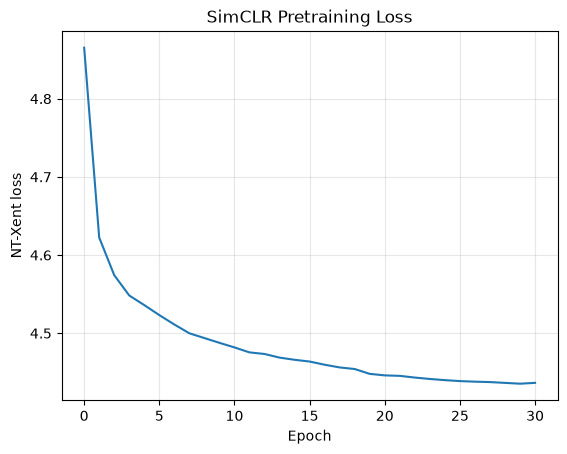

In [50]:
# --- Contrastive pretraining on KNOWN classes only, no labels used ---
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

try:
    from tqdm import tqdm
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'tqdm', '-q'])
    from tqdm import tqdm

def nt_xent_loss(z1, z2, temperature=0.5):
    B = z1.shape[0]
    z = torch.cat([z1, z2], dim=0)
    sim = torch.matmul(z, z.T) / temperature
    mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
    sim = sim.masked_fill(mask, -1e4)
    targets = torch.cat([torch.arange(B, 2 * B), torch.arange(0, B)]).to(z.device)
    return F.cross_entropy(sim, targets)

SUBSET_SIZE = 90000
print(f"Original data size: {len(X_train)}")
np.random.seed(42)
indices = np.random.choice(len(X_train), SUBSET_SIZE, replace=False)
X_train_subset = X_train[indices]
y_train_subset = y_train[indices]
snr_train_subset = snr_train[indices]
print(f"Subset data size: {len(X_train_subset)}")

BATCH_SIZE = 256
EMBED_DIM = 130
PROJ_DIM = 64
EPOCHS = 31
LR = 3e-4

train_contrastive_ds = ContrastiveIQDataset(X_train_subset)
train_contrastive_loader = DataLoader(train_contrastive_ds, batch_size=BATCH_SIZE,
                                       shuffle=True, num_workers=0, drop_last=True,
                                       pin_memory=True)

print(f"Batches per epoch: {len(train_contrastive_loader)}")
print("="*50)

encoder = IQEncoder(embed_dim=EMBED_DIM).to(device)
proj_head = ProjectionHead(embed_dim=EMBED_DIM, proj_dim=PROJ_DIM).to(device)

optimizer = torch.optim.Adam(list(encoder.parameters()) + list(proj_head.parameters()), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

pretrain_losses = []
best_loss = float("inf")
patience, patience_counter = 8, 0
best_encoder_state = None

print("\nStarting training...")
print("="*50)

for epoch in range(EPOCHS):
    encoder.train()
    proj_head.train()
    running_loss = 0.0
    pbar = tqdm(train_contrastive_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for x1, x2 in pbar:
        x1, x2 = x1.to(device, non_blocking=True), x2.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            z1 = proj_head(encoder(x1))
            z2 = proj_head(encoder(x2))
            loss = nt_xent_loss(z1, z2)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    scheduler.step()
    avg_loss = running_loss / len(train_contrastive_loader)
    pretrain_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | contrastive loss: {avg_loss:.4f}")

    if avg_loss < best_loss - 1e-4:
        best_loss = avg_loss
        patience_counter = 0
        best_encoder_state = {k: v.cpu().clone() for k, v in encoder.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} (loss plateaued)")
            break

if best_encoder_state is not None:
    encoder.load_state_dict(best_encoder_state)
    print("Loaded best encoder state from early stopping")

# --- NEW: actually persist to disk so a kernel restart doesn't lose this ---
torch.save(encoder.state_dict(), "encoder_256qam_best.pt")
print("Saved encoder weights to encoder_256qam_best.pt")

print("\nTraining complete! Plotting loss...")
plt.plot(pretrain_losses)
plt.xlabel("Epoch")
plt.ylabel("NT-Xent loss")
plt.title("SimCLR Pretraining Loss")
plt.grid(alpha=0.3)
plt.show()

Extracting embeddings...

Training linear probe...
C=   0.0, Val accuracy: 0.3386
C=   0.0, Val accuracy: 0.3616
C=   0.1, Val accuracy: 0.3867
C=   1.0, Val accuracy: 0.4056
C=  10.0, Val accuracy: 0.4142
C= 100.0, Val accuracy: 0.4201

--- Final Results ---
Linear probe closed-set accuracy: 0.4171
Validation accuracy: 0.4201
Random baseline: 0.0435

--- Per-class accuracy ---
Class  0: 0.7123
Class  1: 0.5662
Class  2: 0.6072
Class  3: 0.7169
Class  4: 0.6672
Class  5: 0.3246
Class  6: 0.1985
Class  7: 0.1867
Class  8: 0.4482
Class  9: 0.5123
Class 10: 0.0677
Class 11: 0.1749
Class 12: 0.1231
Class 13: 0.0621
Class 14: 0.0841
Class 15: 0.0436
Class 17: 0.4021
Class 18: 0.5595
Class 19: 0.5036
Class 20: 0.4559
Class 21: 0.7995
Class 22: 0.7133
Class 23: 0.6636


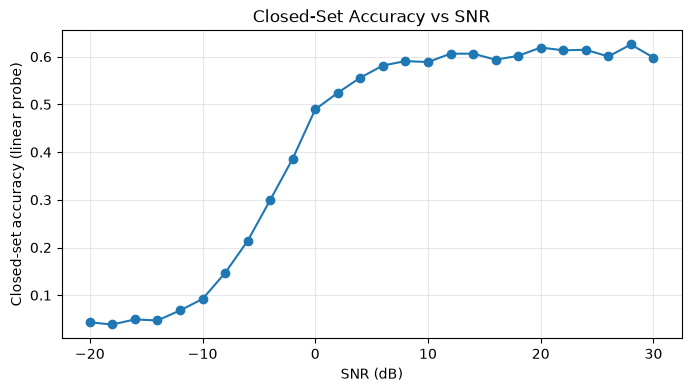

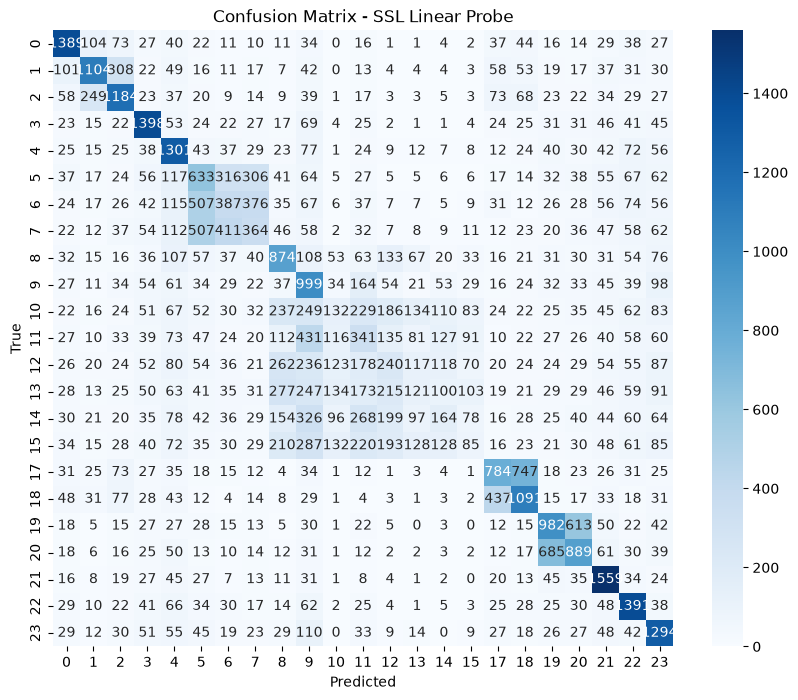

In [60]:
# --- Freeze encoder, extract embeddings, linear probe for closed-set accuracy ---

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
import seaborn as sns

@torch.no_grad()
def get_embeddings(encoder, X, batch_size=512):
    encoder.eval()
    X_t = torch.from_numpy(X).float().permute(0, 2, 1)
    embs = []
    for i in range(0, len(X_t), batch_size):
        batch = X_t[i:i+batch_size].to(device)
        embs.append(encoder(batch).cpu().numpy())
    return np.concatenate(embs, axis=0)

# Extract embeddings
print("Extracting embeddings...")
emb_train = get_embeddings(encoder, X_train)
emb_val = get_embeddings(encoder, X_val)
emb_test = get_embeddings(encoder, X_test)
emb_unk = get_embeddings(encoder, X_unk) 

# Train linear probe with validation
print("\nTraining linear probe...")
best_acc = 0
best_probe = None
for C in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    probe = LogisticRegression(max_iter=2000, random_state=SEED, C=C)
    probe.fit(emb_train, y_train)
    val_acc = accuracy_score(y_val, probe.predict(emb_val))
    print(f"C={C:6.1f}, Val accuracy: {val_acc:.4f}")
    if val_acc > best_acc:
        best_acc = val_acc
        best_probe = probe

probe = best_probe
probe_pred = probe.predict(emb_test)
test_acc = accuracy_score(y_test, probe_pred)

print(f"\n--- Final Results ---")
print(f"Linear probe closed-set accuracy: {test_acc:.4f}")
print(f"Validation accuracy: {best_acc:.4f}")

# Compare with random baseline
dummy = DummyClassifier(strategy='most_frequent').fit(emb_train, y_train)
print(f"Random baseline: {accuracy_score(y_test, dummy.predict(emb_test)):.4f}")

# Per-class accuracy
print("\n--- Per-class accuracy ---")
for class_id in np.unique(y_test):
    mask = y_test == class_id
    acc = accuracy_score(y_test[mask], probe_pred[mask])
    print(f"Class {class_id:2d}: {acc:.4f}")

# SNR-stratified closed-set accuracy
snr_bins = sorted(np.unique(snr_test))
closed_set_by_snr = []
for s in snr_bins:
    mask = snr_test == s
    acc = accuracy_score(y_test[mask], probe_pred[mask]) if mask.sum() > 0 else np.nan
    closed_set_by_snr.append(acc)

plt.figure(figsize=(8, 4))
plt.plot(snr_bins, closed_set_by_snr, marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Closed-set accuracy (linear probe)")
plt.title("Closed-Set Accuracy vs SNR")
plt.grid(alpha=0.3)
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, probe_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - SSL Linear Probe')
plt.show()

✓ emb_train shape: (209300, 130)
✓ emb_test shape: (44850, 130)
✓ emb_unk shape: (13000, 130)
✓ y_train shape: (209300,)
✓ Unique classes in y_train: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 17 18 19 20 21 22 23]

Known classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 17 18 19 20 21 22 23]

Computing class means...
Class 0: 9100 samples, mean shape: (130,)
Class 1: 9100 samples, mean shape: (130,)
Class 2: 9100 samples, mean shape: (130,)
Class 3: 9100 samples, mean shape: (130,)
Class 4: 9100 samples, mean shape: (130,)
Class 5: 9100 samples, mean shape: (130,)
Class 6: 9100 samples, mean shape: (130,)
Class 7: 9100 samples, mean shape: (130,)
Class 8: 9100 samples, mean shape: (130,)
Class 9: 9100 samples, mean shape: (130,)
Class 10: 9100 samples, mean shape: (130,)
Class 11: 9100 samples, mean shape: (130,)
Class 12: 9100 samples, mean shape: (130,)
Class 13: 9100 samples, mean shape: (130,)
Class 14: 9100 samples, mean shape: (130,)
Class 15: 9100 samples, mean sh

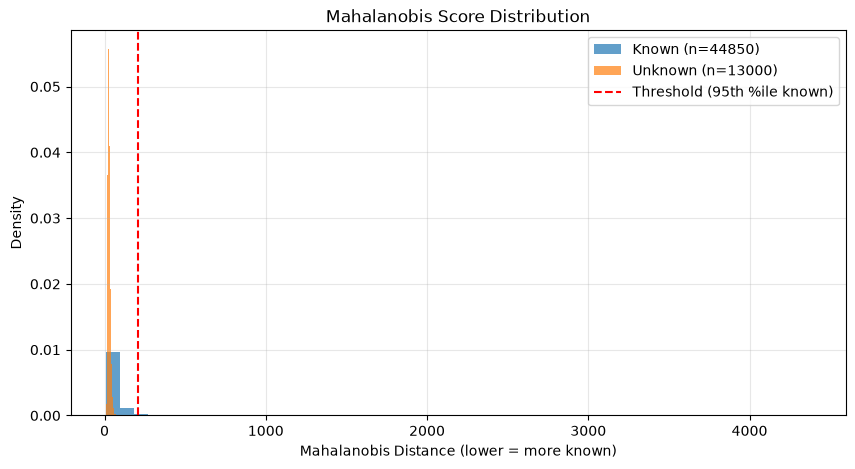

In [61]:
# --- Open-set scoring: Mahalanobis distance ---
from sklearn.covariance import LedoitWolf
from sklearn.metrics import roc_auc_score
import numpy as np

# Check if embeddings exist (they should from previous cell)
try:
    print(f"✓ emb_train shape: {emb_train.shape}")
    print(f"✓ emb_test shape: {emb_test.shape}")
    print(f"✓ emb_unk shape: {emb_unk.shape}")
    print(f"✓ y_train shape: {y_train.shape}")
    print(f"✓ Unique classes in y_train: {np.unique(y_train)}")
except NameError as e:
    print(f"❌ ERROR: {e}")
    print("Please run the embedding extraction cell first!")
    raise

# Define known class IDs (all classes in training set)
KNOWN_IDS = np.unique(y_train)
print(f"\nKnown classes: {KNOWN_IDS}")

def mahalanobis_score(embs, class_means, precision):
    """Min Mahalanobis distance to any known-class mean.
    Returns: LOWER score = MORE known (original distance)
    """
    dists = []
    for c, mu in class_means.items():
        diff = embs - mu
        d = np.einsum("ij,jk,ik->i", diff, precision, diff)
        dists.append(d)
    min_dists = np.stack(dists, axis=1).min(axis=1)
    # NO INVERSION: Keep lower = more known
    return min_dists

# Compute class means from training embeddings
print("\nComputing class means...")
class_means = {}
for c in KNOWN_IDS:
    class_means[c] = emb_train[y_train == c].mean(axis=0)
    print(f"Class {c}: {np.sum(y_train == c)} samples, mean shape: {class_means[c].shape}")

# Compute precision matrix (inverse covariance)
print("\nComputing precision matrix...")
centered = np.concatenate([emb_train[y_train == c] - class_means[c] for c in KNOWN_IDS], axis=0)
print(f"Centered data shape: {centered.shape}")

cov_estimator = LedoitWolf().fit(centered)
precision = cov_estimator.precision_
print(f"Precision matrix shape: {precision.shape}")

# Get scores (LOWER = more known)
print("\nComputing Mahalanobis scores...")
score_known = mahalanobis_score(emb_test, class_means, precision)
score_unk = mahalanobis_score(emb_unk, class_means, precision)

print(f"Known scores: min={score_known.min():.4f}, max={score_known.max():.4f}, mean={score_known.mean():.4f}")
print(f"Unknown scores: min={score_unk.min():.4f}, max={score_unk.max():.4f}, mean={score_unk.mean():.4f}")

# Create labels: 0 = known, 1 = unknown (OOD)
ood_labels = np.concatenate([np.zeros(len(score_known)), np.ones(len(score_unk))])
scores = np.concatenate([score_known, score_unk])

# Calculate AUROC: Since lower scores = known, we negate scores for ROC
# (ROC expects higher scores = positive class, which is "known" here)
auroc = roc_auc_score(ood_labels, -scores)  # Negate so known samples get higher scores

# Calculate FPR95: At 95% TPR, what's the FPR?
# For FPR95, we want the threshold where TPR=95% (i.e., 95% of known samples are correctly identified)
# Since lower scores = more known, we find the 95th percentile of known scores
# Any unknown sample with score <= this threshold is misclassified as known (false positive)
thr = np.percentile(score_known, 95)  # 95th percentile (high threshold)
fpr95 = (score_unk <= thr).mean()  # OOD samples with score <= threshold are misclassified as known

print(f"\n--- Open-Set Detection Results ---")
print(f"Mahalanobis distance AUROC: {auroc:.4f} | FPR95: {fpr95:.4f}")
print(f"Threshold (95th percentile of known): {thr:.4f}")

# Additional diagnostics
print(f"\n--- Diagnostics ---")
print(f"Known samples: {len(score_known)}, Unknown samples: {len(score_unk)}")
print(f"Percentage of unknown scores <= threshold: {fpr95*100:.2f}%")
print(f"Percentage of known scores <= threshold: {(score_known <= thr).mean()*100:.2f}% (should be ~95%)")

# Visualize score distributions
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(score_known, bins=50, alpha=0.7, label=f'Known (n={len(score_known)})', density=True)
plt.hist(score_unk, bins=50, alpha=0.7, label=f'Unknown (n={len(score_unk)})', density=True)
plt.axvline(thr, color='red', linestyle='--', label=f'Threshold (95th %ile known)')
plt.xlabel('Mahalanobis Distance (lower = more known)')
plt.ylabel('Density')
plt.title('Mahalanobis Score Distribution')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [62]:
import numpy as np
from sklearn.preprocessing import normalize
from sklearn.covariance import LedoitWolf

KNOWN_IDS = sorted(np.unique(y_train))

# normalize embeddings
emb_train_n = normalize(emb_train)
emb_test_n  = normalize(emb_test)
emb_unk_n   = normalize(emb_unk)

# per-class mean (normalized space)
class_means = {c: emb_train_n[y_train == c].mean(0) for c in KNOWN_IDS}

# shared precision matrix (tied covariance, Ledoit-Wolf shrinkage for stability)
lw = LedoitWolf().fit(emb_train_n)
precision = lw.precision_

# background Gaussian (all known training data pooled)
bg_mean = emb_train_n.mean(0)
bg_precision = precision  # same shrinkage estimate; fine to reuse

def min_mahalanobis(embs, class_means, precision):
    dists = []
    for mu in class_means.values():
        diff = embs - mu
        d = np.einsum("ij,jk,ik->i", diff, precision, diff)
        dists.append(d)
    return np.stack(dists, axis=1).min(axis=1)

def relative_mahalanobis(embs, class_means, precision, bg_mean, bg_precision):
    min_d = min_mahalanobis(embs, class_means, precision)
    diff_bg = embs - bg_mean
    d_bg = np.einsum("ij,jk,ik->i", diff_bg, bg_precision, diff_bg)
    return min_d - d_bg  # lower = more known, same convention as before

score_known_maha = relative_mahalanobis(emb_test_n, class_means, precision, bg_mean, bg_precision)
score_unk_maha   = relative_mahalanobis(emb_unk_n,  class_means, precision, bg_mean, bg_precision)

print("Maha known  mean/median:", score_known_maha.mean(), np.median(score_known_maha))
print("Maha unk    mean/median:", score_unk_maha.mean(),   np.median(score_unk_maha))

Maha known  mean/median: -6.16014 -2.3590193
Maha unk    mean/median: -1.4916737 -1.5093632


In [54]:
probs_known = probe.predict_proba(emb_test)   # unnormalized embeddings, same as probe was trained on
probs_unk   = probe.predict_proba(emb_unk)

score_known_msp = probs_known.max(axis=1)   # higher = more known
score_unk_msp   = probs_unk.max(axis=1)

print("MSP known mean/median:", score_known_msp.mean(), np.median(score_known_msp))
print("MSP unk   mean/median:", score_unk_msp.mean(),   np.median(score_unk_msp))

MSP known mean/median: 0.4098542 0.27221486
MSP unk   mean/median: 0.18455558 0.17160717


In [55]:
from sklearn.metrics import roc_auc_score

def eval_ood(score_known, score_unk, higher_is_known=True, snr_test=None, snr_unk=None, snr_floor=None):
    if snr_floor is not None:
        mk = snr_test >= snr_floor
        mu = snr_unk  >= snr_floor
        sk, su = score_known[mk], score_unk[mu]
    else:
        sk, su = score_known, score_unk

    labels = np.concatenate([np.zeros(len(sk)), np.ones(len(su))])  # 1 = unknown
    scores = np.concatenate([sk, su])

    # roc_auc_score wants higher score = more positive class (unknown).
    # if higher_is_known, flip sign so higher = more unknown.
    auroc = roc_auc_score(labels, -scores if higher_is_known else scores)

    if higher_is_known:
        thr = np.percentile(sk, 5)      # keep 95% of known above this
        fpr95 = (su >= thr).mean()
    else:
        thr = np.percentile(sk, 95)     # keep 95% of known below this
        fpr95 = (su <= thr).mean()

    return auroc, fpr95, len(sk), len(su)

In [56]:
results = {}

# Mahalanobis: lower = known -> higher_is_known=False
results['maha_full'] = eval_ood(score_known_maha, score_unk_maha, higher_is_known=False)
results['maha_snr0'] = eval_ood(score_known_maha, score_unk_maha, higher_is_known=False,
                                 snr_test=snr_test, snr_unk=snr_unk, snr_floor=0)

# MSP: higher = known -> higher_is_known=True
results['msp_full'] = eval_ood(score_known_msp, score_unk_msp, higher_is_known=True)
results['msp_snr0'] = eval_ood(score_known_msp, score_unk_msp, higher_is_known=True,
                                snr_test=snr_test, snr_unk=snr_unk, snr_floor=0)

for k, (auroc, fpr95, nk, nu) in results.items():
    print(f"{k:12s}  AUROC={auroc:.4f}  FPR95={fpr95:.4f}  (n_known={nk}, n_unk={nu})")

maha_full     AUROC=0.6335  FPR95=0.9524  (n_known=44850, n_unk=13000)
maha_snr0     AUROC=0.7895  FPR95=0.8752  (n_known=27716, n_unk=8000)
msp_full      AUROC=0.6744  FPR95=0.9475  (n_known=44850, n_unk=13000)
msp_snr0      AUROC=0.8264  FPR95=0.8490  (n_known=27716, n_unk=8000)


In [57]:
def zscore(x, ref_mean, ref_std):
    return (x - ref_mean) / (ref_std + 1e-8)

# flip maha so higher = known, then z-score using known stats
maha_known_flipped = -score_known_maha
maha_unk_flipped   = -score_unk_maha
m_mean, m_std = maha_known_flipped.mean(), maha_known_flipped.std()

maha_known_z = zscore(maha_known_flipped, m_mean, m_std)
maha_unk_z   = zscore(maha_unk_flipped,   m_mean, m_std)

msp_mean, msp_std = score_known_msp.mean(), score_known_msp.std()
msp_known_z = zscore(score_known_msp, msp_mean, msp_std)
msp_unk_z   = zscore(score_unk_msp,   msp_mean, msp_std)

score_known_avg = (maha_known_z + msp_known_z) / 2
score_unk_avg   = (maha_unk_z + msp_unk_z) / 2

results['avg_full'] = eval_ood(score_known_avg, score_unk_avg, higher_is_known=True)
results['avg_snr0'] = eval_ood(score_known_avg, score_unk_avg, higher_is_known=True,
                                snr_test=snr_test, snr_unk=snr_unk, snr_floor=0)

print(f"avg_full   AUROC={results['avg_full'][0]:.4f}  FPR95={results['avg_full'][1]:.4f}")
print(f"avg_snr0   AUROC={results['avg_snr0'][0]:.4f}  FPR95={results['avg_snr0'][1]:.4f}")

avg_full   AUROC=0.6638  FPR95=0.9488
avg_snr0   AUROC=0.8277  FPR95=0.8470


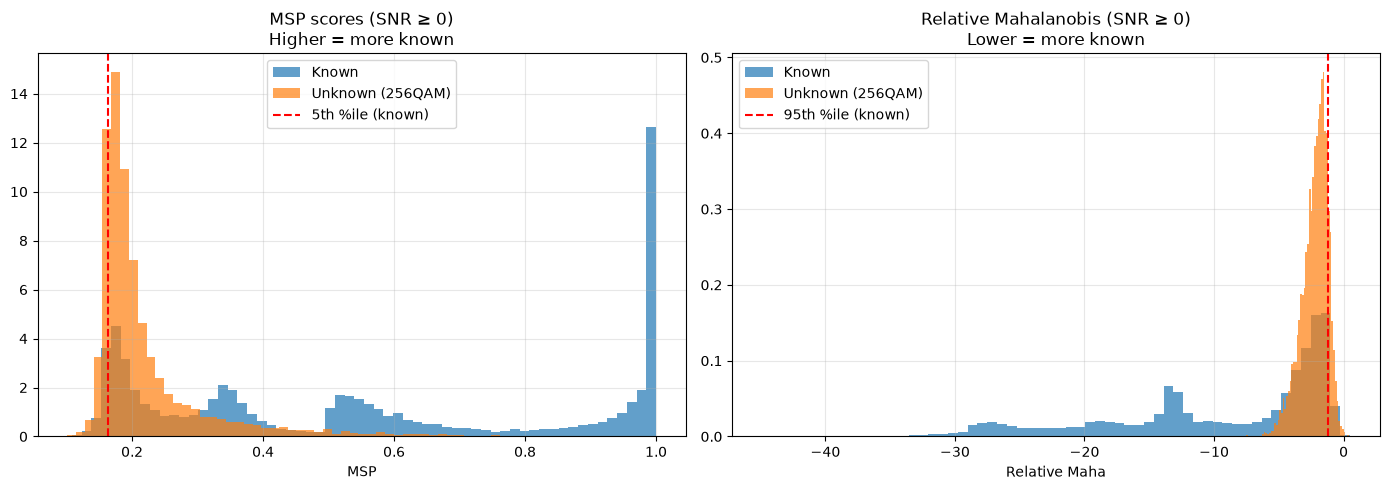

Weight MSP=0.5 | AUROC=0.8280 | FPR95=0.8468 | n_known=27716, n_unk=8000
Weight MSP=0.6 | AUROC=0.8287 | FPR95=0.8479 | n_known=27716, n_unk=8000
Weight MSP=0.7 | AUROC=0.8287 | FPR95=0.8472 | n_known=27716, n_unk=8000
Weight MSP=0.8 | AUROC=0.8282 | FPR95=0.8474 | n_known=27716, n_unk=8000
Weight MSP=0.9 | AUROC=0.8274 | FPR95=0.8486 | n_known=27716, n_unk=8000

--- Temperature scaling on MSP ---
T=0.5 | AUROC=0.8021 | FPR95=0.8390
T=0.7 | AUROC=0.8160 | FPR95=0.8433
T=1.0 | AUROC=0.8264 | FPR95=0.8490
T=1.5 | AUROC=0.8316 | FPR95=0.8531
T=2.0 | AUROC=0.8311 | FPR95=0.8605


In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# ============================================================
# 1. Helper evaluation function
# ============================================================
def eval_ood(score_known, score_unk, higher_is_known=True, snr_floor=None):
    if snr_floor is not None:
        mk = snr_test >= snr_floor
        mu = snr_unk  >= snr_floor
        sk, su = score_known[mk], score_unk[mu]
    else:
        sk, su = score_known, score_unk

    labels = np.concatenate([np.zeros(len(sk)), np.ones(len(su))])  # 1 = unknown
    scores = np.concatenate([sk, su])

    auroc = roc_auc_score(labels, -scores if higher_is_known else scores)

    if higher_is_known:
        thr = np.percentile(sk, 5)          # keep 95% of known
        fpr95 = (su >= thr).mean()
    else:
        thr = np.percentile(sk, 95)
        fpr95 = (su <= thr).mean()

    return auroc, fpr95, len(sk), len(su), thr

# ============================================================
# 2. Histograms (SNR >= 0) – most important diagnostic
# ============================================================
mask_k = snr_test >= 0
mask_u = snr_unk  >= 0

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(score_known_msp[mask_k], bins=60, alpha=0.7, density=True, label="Known")
plt.hist(score_unk_msp[mask_u],   bins=60, alpha=0.7, density=True, label="Unknown (256QAM)")
plt.axvline(np.percentile(score_known_msp[mask_k], 5), color="red", linestyle="--", label="5th %ile (known)")
plt.title("MSP scores (SNR ≥ 0)\nHigher = more known")
plt.xlabel("MSP")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(score_known_maha[mask_k], bins=60, alpha=0.7, density=True, label="Known")
plt.hist(score_unk_maha[mask_u],   bins=60, alpha=0.7, density=True, label="Unknown (256QAM)")
plt.axvline(np.percentile(score_known_maha[mask_k], 95), color="red", linestyle="--", label="95th %ile (known)")
plt.title("Relative Mahalanobis (SNR ≥ 0)\nLower = more known")
plt.xlabel("Relative Maha")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 3. Better combination of MSP + Mahalanobis
# ============================================================
def zscore(x, ref):
    return (x - ref.mean()) / (ref.std() + 1e-8)

# Flip Maha so higher = known, then z-score both using known statistics
maha_known_flip = -score_known_maha
maha_unk_flip   = -score_unk_maha

maha_k_z = zscore(maha_known_flip, maha_known_flip[mask_k])
maha_u_z = zscore(maha_unk_flip,   maha_known_flip[mask_k])

msp_k_z  = zscore(score_known_msp, score_known_msp[mask_k])
msp_u_z  = zscore(score_unk_msp,   score_known_msp[mask_k])

# Try different weights (MSP is stronger, so give it more weight)
for w_msp in [0.5, 0.6, 0.7, 0.8, 0.9]:
    w_maha = 1.0 - w_msp
    sk = w_msp * msp_k_z + w_maha * maha_k_z
    su = w_msp * msp_u_z + w_maha * maha_u_z

    auroc, fpr95, nk, nu, thr = eval_ood(sk, su, higher_is_known=True, snr_floor=0)
    print(f"Weight MSP={w_msp:.1f} | AUROC={auroc:.4f} | FPR95={fpr95:.4f} | n_known={nk}, n_unk={nu}")

# ============================================================
# 4. Quick temperature scaling on MSP (sometimes helps FPR95)
# ============================================================
print("\n--- Temperature scaling on MSP ---")
for T in [0.5, 0.7, 1.0, 1.5, 2.0]:
    # Soften / sharpen the probabilities
    probs_k = probe.predict_proba(emb_test)
    probs_u = probe.predict_proba(emb_unk)

    # temperature scaling
    probs_k_t = np.exp(np.log(probs_k + 1e-12) / T)
    probs_k_t /= probs_k_t.sum(axis=1, keepdims=True)

    probs_u_t = np.exp(np.log(probs_u + 1e-12) / T)
    probs_u_t /= probs_u_t.sum(axis=1, keepdims=True)

    sk = probs_k_t.max(axis=1)
    su = probs_u_t.max(axis=1)

    auroc, fpr95, nk, nu, _ = eval_ood(sk, su, higher_is_known=True, snr_floor=0)
    print(f"T={T:.1f} | AUROC={auroc:.4f} | FPR95={fpr95:.4f}")

In [63]:
import numpy as np
import pandas as pd

# What known class does the probe predict for the unknown (256QAM) samples?
unk_pred = probe.predict(emb_unk)
unk_pred_names = [CLASS_NAMES[c] for c in unk_pred]

pred_counts = pd.Series(unk_pred_names).value_counts()
print("--- Where 256QAM samples get classified (full SNR range) ---")
print(pred_counts.head(10))
print(f"\nTotal unknown samples: {len(unk_pred)}")

# Same, restricted to SNR >= 0 dB (matches your eval floor)
mask0 = snr_unk >= 0
unk_pred0_names = [CLASS_NAMES[c] for c in unk_pred[mask0]]
pred_counts0 = pd.Series(unk_pred0_names).value_counts()
print("\n--- Same, SNR >= 0 dB only ---")
print(pred_counts0.head(10))
print(f"\nTotal unknown samples (SNR>=0): {mask0.sum()}")

# Cross-check: which known class mean is each unknown sample nearest to,
# using the same normalized-embedding Mahalanobis distances (not just probe logits)
dists_per_class = {}
for c in KNOWN_IDS:
    diff = emb_unk_n - class_means[c]
    dists_per_class[c] = np.einsum("ij,jk,ik->i", diff, precision, diff)
nearest_class = np.array(list(dists_per_class.keys()))[
    np.argmin(np.stack(list(dists_per_class.values()), axis=1), axis=1)
]
nearest_names = [CLASS_NAMES[c] for c in nearest_class]
print("\n--- Nearest known class by Mahalanobis distance (full SNR range) ---")
print(pd.Series(nearest_names).value_counts().head(10))

--- Where 256QAM samples get classified (full SNR range) ---
32APSK     2549
128APSK    1762
16QAM      1235
64QAM      1037
16APSK      889
32QAM       628
64APSK      621
128QAM      550
OQPSK       529
QPSK        422
Name: count, dtype: int64

Total unknown samples: 13000

--- Same, SNR >= 0 dB only ---
32APSK     1856
128APSK    1492
16QAM      1166
64QAM       985
16APSK      740
64APSK      584
32QAM       584
128QAM      491
OQPSK        69
QPSK         17
Name: count, dtype: int64

Total unknown samples (SNR>=0): 8000

--- Nearest known class by Mahalanobis distance (full SNR range) ---
32APSK     3953
16APSK     1489
128APSK    1142
16QAM      1034
64QAM       827
OQPSK       812
128QAM      716
QPSK        614
16PSK       561
64APSK      561
Name: count, dtype: int64


In [64]:
# --- SNR-floor sweep: eval-only, no retraining ---
# Reuses the single trained encoder + Mahalanobis scorer from the cell above.
# We do NOT retrain per floor -- we just filter which SNR bins get scored,
# sweeping the floor upward and reporting AUROC/FPR95 at every step (not just
# the best-looking stopping point).

import pandas as pd

snr_floors = sorted(np.unique(snr_test))  # e.g. -20, -18, ..., 28, 30
sweep_results = []

for floor in snr_floors:
    mask_known = snr_test >= floor
    mask_unk   = snr_unk >= floor

    n_known = mask_known.sum()
    n_unk = mask_unk.sum()
    if n_known == 0 or n_unk == 0:
        continue

    sk = score_known[mask_known]
    su = score_unk[mask_unk]

    labels_f = np.concatenate([np.zeros(len(sk)), np.ones(len(su))])
    scores_f = np.concatenate([sk, su])
    auroc_f = roc_auc_score(labels_f, -scores_f)

    thr_f = np.percentile(sk, 95)
    fpr95_f = (su <= thr_f).mean()

    sweep_results.append({
        "snr_floor": floor, "auroc": auroc_f, "fpr95": fpr95_f,
        "n_known": int(n_known), "n_unk": int(n_unk)
    })
    print(f"SNR >= {floor:4d} dB | AUROC: {auroc_f:.4f} | FPR95: {fpr95_f:.4f} | n_known={n_known}, n_unk={n_unk}")

sweep_df = pd.DataFrame(sweep_results)
sweep_df


SNR >=  -20 dB | AUROC: 0.6562 | FPR95: 1.0000 | n_known=44850, n_unk=13000
SNR >=  -18 dB | AUROC: 0.6626 | FPR95: 1.0000 | n_known=43180, n_unk=12500
SNR >=  -16 dB | AUROC: 0.6703 | FPR95: 1.0000 | n_known=41471, n_unk=12000
SNR >=  -14 dB | AUROC: 0.6783 | FPR95: 1.0000 | n_known=39788, n_unk=11500
SNR >=  -12 dB | AUROC: 0.6869 | FPR95: 1.0000 | n_known=38108, n_unk=11000
SNR >=  -10 dB | AUROC: 0.6956 | FPR95: 1.0000 | n_known=36405, n_unk=10500
SNR >=   -8 dB | AUROC: 0.7041 | FPR95: 1.0000 | n_known=34689, n_unk=10000
SNR >=   -6 dB | AUROC: 0.7107 | FPR95: 1.0000 | n_known=32984, n_unk=9500
SNR >=   -4 dB | AUROC: 0.7136 | FPR95: 1.0000 | n_known=31239, n_unk=9000
SNR >=   -2 dB | AUROC: 0.7137 | FPR95: 1.0000 | n_known=29422, n_unk=8500
SNR >=    0 dB | AUROC: 0.7129 | FPR95: 1.0000 | n_known=27716, n_unk=8000
SNR >=    2 dB | AUROC: 0.7108 | FPR95: 1.0000 | n_known=25994, n_unk=7500
SNR >=    4 dB | AUROC: 0.7089 | FPR95: 1.0000 | n_known=24308, n_unk=7000
SNR >=    6 dB | A

,snr_floor,auroc,fpr95,n_known,n_unk
0,-20,0.656210,1.0,44850,13000
1,-18,0.662623,1.0,43180,12500
2,-16,0.670287,1.0,41471,12000
3,-14,0.678317,1.0,39788,11500
4,-12,0.686893,1.0,38108,11000
5,-10,0.695563,1.0,36405,10500
6,-8,0.704061,1.0,34689,10000
7,-6,0.710679,1.0,32984,9500
8,-4,0.713648,1.0,31239,9000
9,-2,0.713651,1.0,29422,8500


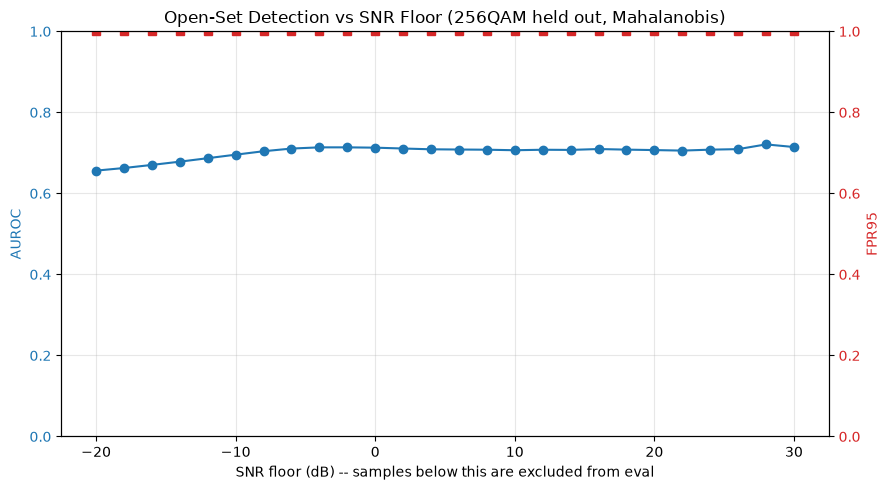

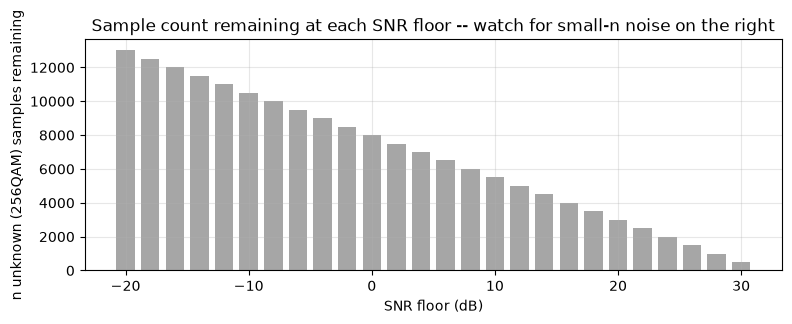

In [65]:
# --- Plot the full sweep curve (this is the reportable result, not the stopping point) ---
# Flag: n_unk shrinks as the floor rises (fewer 256QAM test samples above each floor) --
# report n_unk alongside AUROC/FPR95 so small-sample noise at high floors is visible.

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(sweep_df["snr_floor"], sweep_df["auroc"], marker="o", color="tab:blue", label="AUROC")
ax1.set_xlabel("SNR floor (dB) -- samples below this are excluded from eval")
ax1.set_ylabel("AUROC", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(sweep_df["snr_floor"], sweep_df["fpr95"], marker="s", color="tab:red", label="FPR95")
ax2.set_ylabel("FPR95", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.set_ylim(0, 1)

plt.title("Open-Set Detection vs SNR Floor (256QAM held out, Mahalanobis)")
ax1.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# Sample-size sanity check -- watch for n_unk getting small at high floors
plt.figure(figsize=(9, 3))
plt.bar(sweep_df["snr_floor"], sweep_df["n_unk"], width=1.5, color="gray", alpha=0.7)
plt.xlabel("SNR floor (dB)")
plt.ylabel("n unknown (256QAM) samples remaining")
plt.title("Sample count remaining at each SNR floor -- watch for small-n noise on the right")
plt.grid(alpha=0.3)
plt.show()


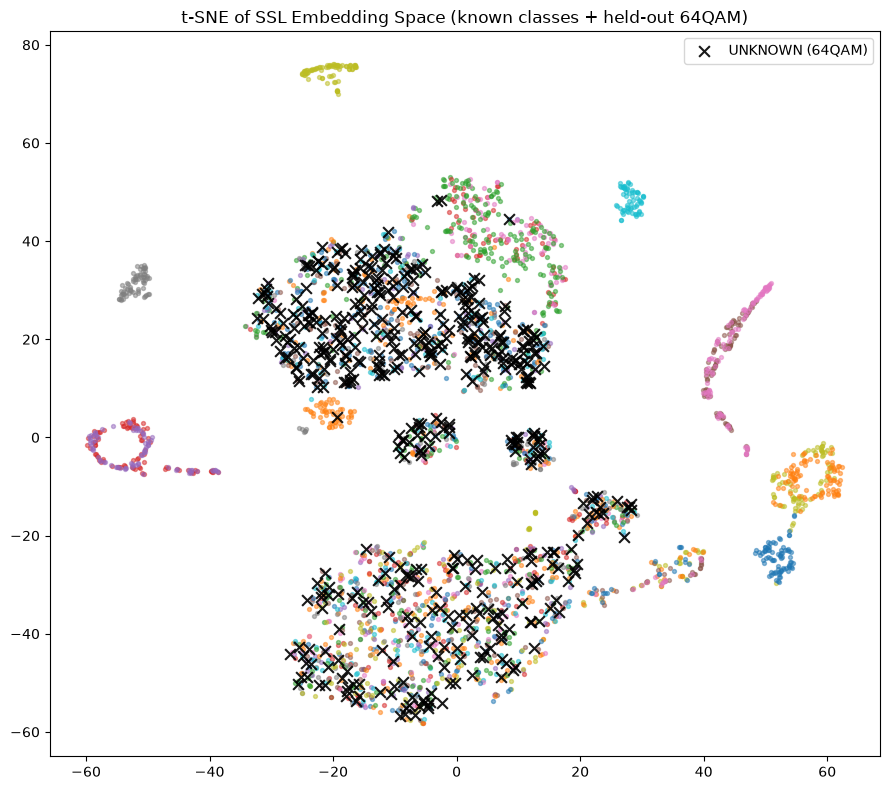

In [66]:
# --- t-SNE of SSL embedding space: known classes + the held-out unknown class ---
# (Use a subsample for speed -- t-SNE is O(n^2)-ish.)

from sklearn.manifold import TSNE

N_TSNE = 3000
rng = np.random.default_rng(SEED)

idx_known = rng.choice(len(emb_test), size=min(N_TSNE, len(emb_test)), replace=False)
idx_unk = rng.choice(len(emb_unk), size=min(500, len(emb_unk)), replace=False)

tsne_input = np.concatenate([emb_test[idx_known], emb_unk[idx_unk]], axis=0)
tsne_labels = np.concatenate([
    [CLASS_NAMES[c] for c in y_test[idx_known]],
    ["UNKNOWN (64QAM)"] * len(idx_unk)
])

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca")
tsne_out = tsne.fit_transform(tsne_input)

plt.figure(figsize=(9, 8))
for lbl in np.unique(tsne_labels):
    mask = tsne_labels == lbl
    is_unknown = lbl.startswith("UNKNOWN")
    plt.scatter(tsne_out[mask, 0], tsne_out[mask, 1],
                s=60 if is_unknown else 8,
                marker="x" if is_unknown else "o",
                c="black" if is_unknown else None,
                alpha=0.9 if is_unknown else 0.5,
                label=lbl if is_unknown else None)
plt.title("t-SNE of SSL Embedding Space (known classes + held-out 64QAM)")
plt.legend()
plt.tight_layout()
plt.show()


In [67]:
# Search your notebook's variables for anything that looks like the class/label list
for name, val in list(globals().items()):
    if isinstance(val, (list, np.ndarray)) and 0 < len(val) <= 30:
        try:
            if any(isinstance(x, str) for x in val):
                print(name, "->", val)
        except:
            pass

classes -> ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']
feature_names -> ['I_mean', 'I_std', 'Q_mean', 'Q_std', 'amp_mean', 'amp_std', 'amp_max', 'phase_mean', 'phase_std', 'power', 'RMS_amp', 'amp_var', 'amp_skew', 'amp_kurtosis', 'amp_min', 'amp_ptp', 'amp_kurt', 'I_skew', 'Q_skew', 'crest_factor', 'papr', 'inst_freq_mean', 'inst_freq_std']
CLASS_NAMES -> ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']
UNKNOWN_CLASS_NAMES -> ['256QAM']
KNOWN_CLASS_NAMES -> ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'A

In [68]:
# --- SNR-floor sweep: eval-only, no retraining ---
import pandas as pd
import numpy as np
snr_floors = sorted(np.unique(snr_test))
sweep_results = []

for floor in snr_floors:
    mask_known = snr_test >= floor
    mask_unk   = snr_unk >= floor

    n_known = mask_known.sum()
    n_unk = mask_unk.sum()
    if n_known == 0 or n_unk == 0:
        continue

    sk = score_known[mask_known]
    su = score_unk[mask_unk]

    labels_f = np.concatenate([np.zeros(len(sk)), np.ones(len(su))])
    scores_f = np.concatenate([sk, su])
    auroc_f = roc_auc_score(labels_f, -scores_f)

    thr_f = np.percentile(sk, 95)
    fpr95_f = (su <= thr_f).mean()

    sweep_results.append({
        "snr_floor": floor, "auroc": auroc_f, "fpr95": fpr95_f,
        "n_known": int(n_known), "n_unk": int(n_unk),
        "threshold": thr_f, "max_unk_score": su.max(), "min_unk_score": su.min()
    })
    print(f"SNR >= {floor:4d} dB | AUROC: {auroc_f:.4f} | FPR95: {fpr95_f:.4f} | "
          f"thr={thr_f:8.2f} | max_unk={su.max():8.2f} | n_known={n_known}, n_unk={n_unk}")

sweep_df = pd.DataFrame(sweep_results)
sweep_df

SNR >=  -20 dB | AUROC: 0.6562 | FPR95: 1.0000 | thr=  206.90 | max_unk=   81.96 | n_known=44850, n_unk=13000
SNR >=  -18 dB | AUROC: 0.6626 | FPR95: 1.0000 | thr=  214.52 | max_unk=   81.96 | n_known=43180, n_unk=12500
SNR >=  -16 dB | AUROC: 0.6703 | FPR95: 1.0000 | thr=  222.62 | max_unk=   81.96 | n_known=41471, n_unk=12000
SNR >=  -14 dB | AUROC: 0.6783 | FPR95: 1.0000 | thr=  231.20 | max_unk=   81.96 | n_known=39788, n_unk=11500
SNR >=  -12 dB | AUROC: 0.6869 | FPR95: 1.0000 | thr=  238.78 | max_unk=   81.96 | n_known=38108, n_unk=11000
SNR >=  -10 dB | AUROC: 0.6956 | FPR95: 1.0000 | thr=  246.09 | max_unk=   81.96 | n_known=36405, n_unk=10500
SNR >=   -8 dB | AUROC: 0.7041 | FPR95: 1.0000 | thr=  252.88 | max_unk=   81.96 | n_known=34689, n_unk=10000
SNR >=   -6 dB | AUROC: 0.7107 | FPR95: 1.0000 | thr=  261.05 | max_unk=   81.96 | n_known=32984, n_unk=9500
SNR >=   -4 dB | AUROC: 0.7136 | FPR95: 1.0000 | thr=  267.43 | max_unk=   81.96 | n_known=31239, n_unk=9000
SNR >=   -2 

,snr_floor,auroc,fpr95,n_known,n_unk,threshold,max_unk_score,min_unk_score
0,-20,0.656210,1.0,44850,13000,206.898804,81.957611,9.495327
1,-18,0.662623,1.0,43180,12500,214.516052,81.957611,9.495327
2,-16,0.670287,1.0,41471,12000,222.622620,81.957611,9.495327
3,-14,0.678317,1.0,39788,11500,231.197632,81.957611,9.495327
4,-12,0.686893,1.0,38108,11000,238.779633,81.957611,9.830355
5,-10,0.695563,1.0,36405,10500,246.087646,81.957611,9.830355
6,-8,0.704061,1.0,34689,10000,252.875900,81.957611,9.830355
7,-6,0.710679,1.0,32984,9500,261.052948,81.957611,9.830355
8,-4,0.713648,1.0,31239,9000,267.432709,81.957611,9.830355
9,-2,0.713651,1.0,29422,8500,276.163086,81.957611,9.830355


In [69]:
import numpy as np
import pandas as pd

# What known class does the probe predict for the unknown (256QAM) samples?
unk_pred = probe.predict(emb_unk)
unk_pred_names = [CLASS_NAMES[c] for c in unk_pred]

pred_counts = pd.Series(unk_pred_names).value_counts()
print("--- Where 256QAM samples get classified (full SNR range) ---")
print(pred_counts.head(10))
print(f"\nTotal unknown samples: {len(unk_pred)}")

# Same, restricted to SNR >= 0 dB (matches your eval floor)
mask0 = snr_unk >= 0
unk_pred0_names = [CLASS_NAMES[c] for c in unk_pred[mask0]]
pred_counts0 = pd.Series(unk_pred0_names).value_counts()
print("\n--- Same, SNR >= 0 dB only ---")
print(pred_counts0.head(10))
print(f"\nTotal unknown samples (SNR>=0): {mask0.sum()}")

# Cross-check: which known class mean is each unknown sample nearest to,
# using the same normalized-embedding Mahalanobis distances (not just probe logits)
dists_per_class = {}
for c in KNOWN_IDS:
    diff = emb_unk_n - class_means[c]
    dists_per_class[c] = np.einsum("ij,jk,ik->i", diff, precision, diff)
nearest_class = np.array(list(dists_per_class.keys()))[
    np.argmin(np.stack(list(dists_per_class.values()), axis=1), axis=1)
]
nearest_names = [CLASS_NAMES[c] for c in nearest_class]
print("\n--- Nearest known class by Mahalanobis distance (full SNR range) ---")
print(pd.Series(nearest_names).value_counts().head(10))

--- Where 256QAM samples get classified (full SNR range) ---
32APSK     2549
128APSK    1762
16QAM      1235
64QAM      1037
16APSK      889
32QAM       628
64APSK      621
128QAM      550
OQPSK       529
QPSK        422
Name: count, dtype: int64

Total unknown samples: 13000

--- Same, SNR >= 0 dB only ---
32APSK     1856
128APSK    1492
16QAM      1166
64QAM       985
16APSK      740
64APSK      584
32QAM       584
128QAM      491
OQPSK        69
QPSK         17
Name: count, dtype: int64

Total unknown samples (SNR>=0): 8000

--- Nearest known class by Mahalanobis distance (full SNR range) ---
32APSK     3953
16APSK     1489
128APSK    1142
16QAM      1034
64QAM       827
OQPSK       812
128QAM      716
QPSK        614
16PSK       561
64APSK      561
Name: count, dtype: int64


In [70]:
print(UNKNOWN_CLASS_NAMES)
print(UNKNOWN_IDS)

['256QAM']
[16]


In [71]:
# --- SNR-floor sweep: eval-only, no retraining ---
# Uses the FIXED scoring (MSP), not the raw broken Mahalanobis.
# Swap score_known_msp/score_unk_msp for score_known_maha/score_unk_maha
# below if you want to sweep relative-Mahalanobis instead.

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

snr_floors = sorted(np.unique(snr_test))
sweep_results = []

for floor in snr_floors:
    mask_known = snr_test >= floor
    mask_unk   = snr_unk >= floor

    n_known = mask_known.sum()
    n_unk = mask_unk.sum()
    if n_known == 0 or n_unk == 0:
        continue

    sk = score_known_msp[mask_known]   # higher = more known
    su = score_unk_msp[mask_unk]

    labels_f = np.concatenate([np.zeros(len(sk)), np.ones(len(su))])
    scores_f = np.concatenate([sk, su])
    auroc_f = roc_auc_score(labels_f, -scores_f)  # flip: higher score = known -> negate for AUROC

    thr_f = np.percentile(sk, 5)      # keep 95% of known above this
    fpr95_f = (su >= thr_f).mean()

    sweep_results.append({
        "snr_floor": floor, "auroc": auroc_f, "fpr95": fpr95_f,
        "n_known": int(n_known), "n_unk": int(n_unk)
    })
    print(f"SNR >= {floor:4d} dB | AUROC: {auroc_f:.4f} | FPR95: {fpr95_f:.4f} | n_known={n_known}, n_unk={n_unk}")

sweep_df = pd.DataFrame(sweep_results)
sweep_df

SNR >=  -20 dB | AUROC: 0.6744 | FPR95: 0.9475 | n_known=44850, n_unk=13000
SNR >=  -18 dB | AUROC: 0.6863 | FPR95: 0.9470 | n_known=43180, n_unk=12500
SNR >=  -16 dB | AUROC: 0.7000 | FPR95: 0.9455 | n_known=41471, n_unk=12000
SNR >=  -14 dB | AUROC: 0.7155 | FPR95: 0.9447 | n_known=39788, n_unk=11500
SNR >=  -12 dB | AUROC: 0.7329 | FPR95: 0.9385 | n_known=38108, n_unk=11000
SNR >=  -10 dB | AUROC: 0.7522 | FPR95: 0.9349 | n_known=36405, n_unk=10500
SNR >=   -8 dB | AUROC: 0.7738 | FPR95: 0.9250 | n_known=34689, n_unk=10000
SNR >=   -6 dB | AUROC: 0.7927 | FPR95: 0.9140 | n_known=32984, n_unk=9500
SNR >=   -4 dB | AUROC: 0.8074 | FPR95: 0.8916 | n_known=31239, n_unk=9000
SNR >=   -2 dB | AUROC: 0.8189 | FPR95: 0.8639 | n_known=29422, n_unk=8500
SNR >=    0 dB | AUROC: 0.8264 | FPR95: 0.8490 | n_known=27716, n_unk=8000
SNR >=    2 dB | AUROC: 0.8295 | FPR95: 0.8385 | n_known=25994, n_unk=7500
SNR >=    4 dB | AUROC: 0.8309 | FPR95: 0.8377 | n_known=24308, n_unk=7000
SNR >=    6 dB | A

,snr_floor,auroc,fpr95,n_known,n_unk
0,-20,0.674355,0.947538,44850,13000
1,-18,0.686301,0.946960,43180,12500
2,-16,0.700008,0.945500,41471,12000
3,-14,0.715496,0.944696,39788,11500
4,-12,0.732944,0.938545,38108,11000
5,-10,0.752159,0.934857,36405,10500
6,-8,0.773782,0.925000,34689,10000
7,-6,0.792697,0.914000,32984,9500
8,-4,0.807366,0.891556,31239,9000
9,-2,0.818874,0.863882,29422,8500
